# Topic 2: Bond & Yields

In [1]:
#libraries and config
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize
import os
from pathlib import Path
import csv


# 1. Bonds
A bond is a fixed income security under which issuer (debtor) owes the holder (creditor) a debt, and is obliged (depending also on the terms) to provide cash flow to the creditor, which usually consists of repaying the principal (the amount borrowed) of the bond at the maturity date (expired date of the bond), as well as interest (called coupon) over a specified amount of time.
- In the most simple case, the received interest rate is fixed. It doesn't over the life of the bond. As a result, bonds offer the security of stable interest payments.
- The timing and the amount of cash flow provided varies, depending on the economic value that could give rise to different types of bonds.

### Bond Issuance

Bonds are issued most of the time by public authorities, credit institutions, companies and supranational institutions int the primary markets. Most common process is through underwriting.

### Characteristics of Bonds:
- **Face value or Par Value**: The value of the bond at maturity and the reference amount the bond issuer uses when calculating interest payments.
- **Coupon Rate**: The rate of interest the bond issuer will pay on the face value of the bond, expressed as a percentage.
- **Coupon Dates**: The dates on which the bond issuer will make interest payments.
- **Maturity Date**: The date on which the bond will mature and the bond issuer will pay the bondholder the face value of the bond.
- **Issue Price**: The price at which the bond issuer originally sells the bonds.Most of the time, bonds are issued at par value.

### Bond Categories:
- **Corporate Bonds**: Companies issue corporate bonds rather than seek bank loans for debt financing because bond markets offer more favorable terms and lower interest rates.
- **Municipal Bonds**: Issued by states and municipalities. Some municipal bonds offer investors tax-free coupon income.
- **Government Bonds**: The U.S. Treasury issues several types of bonds. Those with a year or less to maturity are bills, while notes have one to 10 years until maturity. Government bonds issued with more than 10 years to maturity are called “bonds.” All bonds issued by the treasury are collectively referred to as "Treasuries."
- **Agency Bonds**: Issued by government-affiliated organizations such as Fannie Mae or Freddie Mac.

### Bonds price and interest rates
A bond's price changes daily, where supply and demand determine that observed price. If an investor holds a bond to maturity, they will get their principal back plus interest. However, a bondholder can sell their bonds in the open market, where the price can fluctuate. A bond’s price varies inversely with interest rates. **When rates go up, bond prices fall to equalize the interest rate on the bond with prevailing rates, and vice versa**.

# 2. Datasets for this topic
We'll be using ECB spot rates for different maturities (semi-annual spot yield for a period of 5 years) at January 2, 2025

In [2]:
df=pd.read_csv("yield_curve.csv", parse_dates=True)
df=df[df["DATE"]=="02/01/2025"].reset_index(drop=True)
df

,DATE,TIME PERIOD,AAA yield curve - 6-month spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_6M),AAA yield curve - 1-year spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_1Y),AAA yield curve - 1-year 6-month spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_1Y6M),AAA yield curve - 2-year spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_2Y),AAA yield curve - 2-year 6-month spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_2Y6M),AAA yield curve - 3-year spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_3Y),AAA yield curve - 3-year 6-month spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_3Y6M),AAA yield curve - 4-year spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_4Y),AAA yield curve - 4-year 6-month spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_4Y6M),AAA yield curve - 5-year spot rate (YC.B.U2.EUR.4F.G_N_A.SV_C_YM.SR_5Y)
0,02/01/2025,02-Jan-25,2.425927,2.191738,2.066626,2.00762,1.988808,1.994412,2.01472,2.043686,2.0775,2.113736


In [3]:
maturities=[0.5,1,1.5,2,2.5,3,3.5,4,4.5,5]
spot_rates=df.iloc[0,2:].astype(float).tolist()

## 3. Spot rates

Spot rat is the interest rate at which a person can borrow funds today. This is different from a futures, or forward price, where a price is determined in advance. The spot rate is the current market value based on the balance of supply and demand.

Bond spot rates are based on the zero-coupon rate.
- A zero coupon bond (also called STRIP) is a bond that pays no coupons. As it does not pay coupons, it is sold at a discount from its par value.

### How to derive a spot rate:
- The spot rate is derived through a method called "Bootstrapping" - in which the spote rates are derived from the price of coupon-bearing products (such as bonds, swaps) or from zero-coupon bonds.

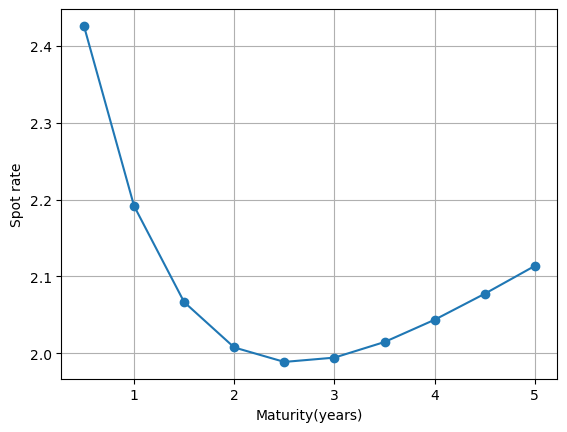

In [4]:
plt.plot(maturities, spot_rates, marker='o')
plt.xlabel("Maturity(years)")
plt.ylabel("Spot rate")
plt.grid(True)
plt.show()

From a macroeconomic perspective, overall in January 2025, we have a slightly inverted at short-to-medium end .short rates are still highs as the ECB maintained a restrictive policy against inflation. Long rates are usually lower as the market anticipated decrease in futures rates, we would expect to see a certain 

# 4. Linear interpolation:

The formula is:
$y_i=y_1 + (y_2 - y_1) * \frac{x_i-x_1}{x_2-x_1}$

We choose for example rate at 2y and 3y, we try to interpolate to get 2.5y

In [5]:
y1=spot_rates[3]
y2=spot_rates[5]
x1=maturities[3]
x2=maturities[5]
xi=maturities[4]
yi=y1+(y2-y1)*(xi-x1)/(x2-x1)
print(f"The spot rate for 2,5 years (interpolated) is approximately {yi:.4f}%")
print(f'spot rate for 2,5 years (market price) is {spot_rates[4]}%')


The spot rate for 2,5 years (interpolated) is approximately 2.0010%
spot rate for 2,5 years (market price) is 1.988808%


Why these rates ares identical?
It is because linear interpolation assumes a straight line between two known points. However, the spot yield curve is non-linear, it has curvature. In the 2y-3y segment, the curve is concave, so the true rate sits below the linear estimate, explaining the small positive difference of 1.2 bps.

# 5.STRIP prices from spot rates
$P=\frac{M}{(1+\frac{y}{m})^(m*n)}$
where M is the principal, y is the spot rate (in decimal), m=period, n= maturity in years

In [6]:
strip_prices=[]
for maturity in maturities:
    price=100/(1+((spot_rates[maturities.index(maturity)]/100) /2))**(2*maturity)
    strip_prices.append(price)
strip_prices

[98.80157298229885,
 97.84377055918739,
 96.9630386969912,
 96.0835354785816,
 95.17293156816389,
 94.22016112491517,
 93.22424148029839,
 92.1887022318488,
 91.11886839625289,
 90.02054904005412]

So why all strips are below par value?
Because strip pays no coupons, its only cash flow is 100 at maturity. Discounting that single future flow back to today at a positive interest rate always gives a present values less than 100. The further away the maturity, the more discounting is applied, so the price gets lower.

# 6. Forward rates from spot rates
A forward rate is the interest rate agreed upon today for a loan or investment that will:
- start at a future date $t_1$
- end at a later future date $t_2$

It is not a prediction, it is a contractual rate locked in now, for a transaction that hasn't started yet.
The forward is:
- agreed today
- for future period
- under no-arbitrage, implied by current spot rates, so it is not independently quoted
    - Investing for $t_2$ years must yield the same as investing for $t_1$ years, then rollong over at the forward rate $f(t_1,t_2) for the remainting $t_2-t_1$ years

Continuous compounding formula:

$$\left(1 + \frac{s_t}{m}\right)^{l_{s_t}} = \left(1 + \frac{s_{t-1}}{m}\right)^{l_{s_{t-1}}} \times \left(1 + \frac{f(t)}{m}\right)^{1}$$

where $l_t$ is just the period number.

Two things to take into account:
- The first forward rate equals the first spot rate.
- For all others, we will need the current and previous spot rate.

We solve for:
$$f(t) = m \left[ \frac{\left(1 + \frac{s_t}{m}\right)^{l_t}}{\left(1 + \frac{s_{t-1}}{m}\right)^{l_{t-1}}} - 1 \right]$$


[0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5]

In [17]:
forward_rates=[spot_rates[0]]
for i in range(1,len(maturities)):
    fwd_rate=2*100*((((1+(spot_rates[i]/200))**(int(maturities[i]*2)))/
                     ((1+(spot_rates[i-1]/200))**(int(maturities[i-1]*2))))
                     -1)
    forward_rates.append(fwd_rate)
forward_rates

[2.425927,
 1.9578199360828386,
 1.8166342021282311,
 1.8307053628467962,
 1.9135775170811442,
 2.022434332256262,
 2.1366108831837316,
 2.2465643259523826,
 2.348215807385712,
 2.440152538305629]

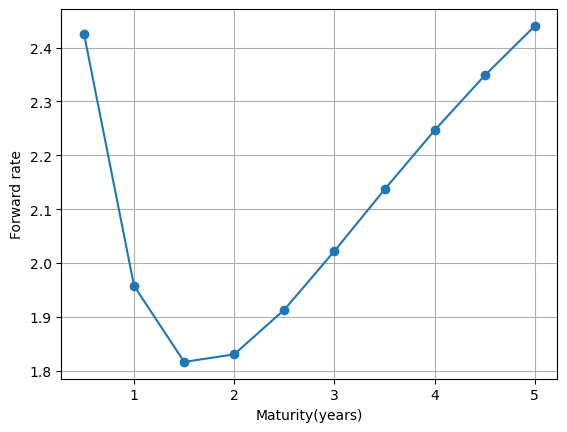

In [18]:
plt.plot(maturities, forward_rates, marker='o')
plt.xlabel("Maturity(years)")
plt.ylabel("Forward rate")
plt.grid(True)
plt.show()

Remarks:
- Upward sloping yield curve -> forward rates above spot rates
- Downward sloping/ inverted yield curve -> forward rates below spot rates
- Forward rates are the marginal rates that stitch together the spot curve: the spot rate $s(T)$ is the geometric average of all forward rates up to $T$

$(1+s(T))^T=\prod_{i}(1+f(t_{i-1}, t_i))$

In our case, the forward curve lies below the spot curve for short maturities, consistent with the inverted segment (0.5y-2.5y), reflecting market expectations of ECB rate cuts.

Practical uses:
- floating rate instruments (FRAs, swap): forward rated define future coupon resets
- Hedging: lock in a borrowing/lending rate for a future period
- Bond pricing: discount future cash flows using the appropriate forward rates
- Monetary policy interpretation: the forward curve reflects market expectations of central bank rate paths

# 7. pricing the 3y French governement bond
Bond parameters:
- Par value: $€1000$
- Annual coupon: $2%$ -> semi-annual coupon = $€10$
- 6 semi-annual periods (3 years)
- Use our first 6 spot rates (0.5y to 3y)

a) Using spot rates:

Formula:
$$P = \sum_{i=1}^{N} \frac{C}{\left(1 + \frac{s_i}{m}\right)^{i}} + \frac{M}{\left(1 + \frac{s_N}{m}\right)^{N}}$$

In [ ]:
def bond_price(coupon_rate, frequency, spot_rates:list, maturities:list, par_value=100):
    price=0
    for i in range(len(maturities[:6])):
        price+=coupon_rate/(1+(spot_rates[i]/200))**(frequency*maturities[i])
    price+=par_value/(1+(spot_rates[i]/200))**(frequency*maturities[i])
    return price
french_bond_3y=bond_price(10,2,spot_rates,maturities,1000)
print(f"The price of the 3-year French bond is approximately {french_bond_3y:.2f}")

The price of the 3-year French bond is approximately 1000.11


b) Using forward rate:
$$P = \sum_{i=1}^{N} \frac{C+M \cdot \mathbb{1}_{i=N}}{\prod_{k=1}^{i}\left(1+\frac{f_k}{m}\right)}$$

In [27]:
def bond_price_fwd(coupon_rate,frequency, forward_rates:list, maturities:list, par_value=100):
    price=0
    discount_factor=1
    for i in range(len(maturities[:6])):
        discount_factor*= (1+forward_rates[i]/200)
        price+=coupon_rate/discount_factor
    price+=par_value/discount_factor
    return price
french_bond_3y_fwd=bond_price_fwd(10,2,forward_rates,maturities,1000)
print(f"The price of the 3-year French bond using forward rates is approximately {french_bond_3y_fwd:.2f}")

The price of the 3-year French bond using forward rates is approximately 1000.11


c) remarks:
Both methods yield the same price (€1000.11). This is not a coincidence - it is a direct consequence of the no-arbitrage condition used to derive the forward rates from spot rates. The two discounting approaches are mathematically equivalent.

# 8. Dirty and clean price
The bond is purchased 50 days after issuance (01 January 2025), so the purchase date is 20 February 2025.
We use 30/360 day-count convention.
3 things needed:
1. Fractional period w:
$$w = \frac{\text{days to next coupon}}{\text{days in coupon period}} = \frac{180 - 50}{180}$$

2. Dirty price
$$P_{dirty} = \sum_{i=0}^{N-1} \frac{C}{\left(1+\frac{s_i}{m}\right)^{i+w}} + \frac{M}{\left(1+\frac{s_N}{m}\right)^{N-1+w}}$$

3. Accrued interest:
$$AI = C \times \frac{\text{days since last coupon}}{\text{days in coupon period}}$$

4. Clean price:
$$P_{clean} = P_{dirty} - AI$$

In [30]:
def dirty_and_clean_price(days_in_period,days_purchased_after_issuance, coupon_rate, frequency, spot_rates:list, maturities:list, par_value=100):
    w=(days_in_period-days_purchased_after_issuance)/days_in_period
    ai=coupon_rate*(days_purchased_after_issuance/days_in_period)

    dirty_price=0
    for i in range(len(maturities[:6])):
        dirty_price+=coupon_rate/(1+(spot_rates[i]/200))**(i+w)
    dirty_price+=par_value/(1+(spot_rates[i]/200))**(i+w)
    clean_price=dirty_price-ai
    return dirty_price, clean_price
dirty_price, clean_price=dirty_and_clean_price(180,50,10,2,spot_rates,maturities,1000)
print(f"The dirty price of the bond is approximately {dirty_price:.2f}")
print(f"The clean price of the bond is approximately {clean_price:.2f}")

The dirty price of the bond is approximately 1002.88
The clean price of the bond is approximately 1000.10


# 9.YTM of the bond
The YTM is the single constant rate $y$ that satisfies:
$$P = \sum_{i=1}^{N} \frac{C}{\left(1 + \frac{YTM}{m}\right)^{i}} + \frac{M}{\left(1 + \frac{YTM}{m}\right)^{N}}$$
$$f(y) = P(y) - P_{target} = 0$$

we already have $P$ in (7a), we will solve for $y$ - there is no closed-form solution so we solve it numerically.
We will implement Newton-Raphson:
$$y_{n+1} = y_n - \frac{f(y_n)}{f'(y_n)}$$

Where:
$$f'(y) = \sum_{i=1}^{N} \frac{-i/m \cdot C}{\left(1 + \frac{y}{m}\right)^{i+1}} + \frac{-N/m \cdot M}{\left(1 + \frac{y}{m}\right)^{N+1}}$$

In [34]:
C = 10          # semi-annual coupon
N = 6           # number of periods
m = 2           # semi-annual
par_value = 1000
target_price = french_bond_3y  # price from Q7a

def bond_price_ytm(ytm, C, N, m, par_value):
    price = 0
    for i in range(1, N+1):
        price += C / (1 + ytm/m) ** i
    price += par_value / (1 + ytm/m) ** N
    return price

def bond_price_derivative(ytm, C, N, m, par_value):
    derivative = 0
    for i in range(1, N+1):
        derivative += (-i/m * C) / (1 + ytm/m) ** (i+1)
    derivative += (-N/m * par_value) / (1 + ytm/m) ** (N+1)
    return derivative

# Newton-Raphson
ytm = 0.02
tolerance = 1e-10

for i in range(1000):
    error = bond_price_ytm(ytm, C, N, m, par_value) - target_price
    if abs(error) < tolerance:
        break
    ytm = ytm - error / bond_price_derivative(ytm, C, N, m, par_value)

print(f"YTM: {ytm*100:.6f}%")
print(f"Converged in {i+1} iterations")
print(f"Verification — price at YTM: {bond_price_ytm(ytm, C, N, m, par_value):.6f}")

YTM: 1.996200%
Converged in 3 iterations
Verification — price at YTM: 1000.110112


The YTM (1.9962%) represents the single constant discount rate that reproduces 
the bond's market price. It is a weighted average of the 6 spot rates, weighted 
by the size of each cash flow. Since the largest cash flow occurs at maturity (year 3), 
the YTM is closest to the 3-year spot rate (1.9944%).

# 10. Bond's volatility
The DV01 (Dollar Value of 01) measures the change in bond price for a 1 basis point (0.01%) change in yield.

$$DV01 = -\frac{\Delta BV}{10{,}000 \times \Delta y}$$

A 5 basis point decrease in YTM is applied to estimate the DV01.
The result indicates the dollar amount by which the bond price changes for every 1bp move in yield.


In [35]:
delta_y = 0.0005  # 5 basis points
 
BV0     = bond_price_ytm(ytm, C, N, m, par_value)
BV_down = bond_price_ytm(ytm - delta_y, C, N, m, par_value)
 
DV01 = -(BV_down - BV0) / (10_000 * (-delta_y))
 
print(f"BV0:            €{BV0:.6f}")
print(f"BV_down (-5bp): €{BV_down:.6f}")
print(f"DV01:           €{DV01:.6f}")
print(f"\nInterpretation: A 1bp change in YTM changes the bond price by €{DV01:.6f}")

BV0:            €1000.110112
BV_down (-5bp): €1001.560416
DV01:           €0.290061

Interpretation: A 1bp change in YTM changes the bond price by €0.290061


(b) **Effective duration** measures the percentage price change for a 1% change in yield:

$$D = \frac{BV_{-\Delta y} - BV_{+\Delta y}}{2 \times BV_0 \times \Delta y}$$

**Convexity** measures the curvature of the price-yield relationship — it corrects the linear approximation of duration for larger yield moves:

$$Cx = \frac{BV_{-\Delta y} + BV_{+\Delta y} - 2 \times BV_0}{BV_0 \times (\Delta y)^2}$$

Duration is a good approximation for small yield changes. For larger moves, convexity becomes necessary to maintain accuracy.

In [37]:
delta_y2 = 0.0055  # 55 basis points
 
BV_minus = bond_price_ytm(ytm - delta_y2, C, N, m, par_value)
BV_plus  = bond_price_ytm(ytm + delta_y2, C, N, m, par_value)
 
duration   = (BV_minus - BV_plus) / (2 * BV0 * delta_y2)
convexity  = (BV_minus + BV_plus - 2 * BV0) / (BV0 * delta_y2 ** 2)
 
print(f"\nBV_ minus delta y: €{BV_minus:.6f}")
print(f"BV_ plus delta y: €{BV_plus:.6f}")
print(f"\nDuration:  {duration:.6f}")
print(f"Convexity: {convexity:.6f}")
print(f"\nDV01 from duration: €{duration * 0.0001 * BV0:.6f}")


BV_ minus delta y: €1016.201493
BV_ plus delta y: €984.320032

Duration:  2.897996
Convexity: 9.959243

DV01 from duration: €0.289831


(c) Price change estimate (Duration + convexity)

$$\Delta BV_{\pm}\% = \underbrace{(-D) \times (\pm \Delta y) \times V}_{\text{duration effect}} + \underbrace{\frac{1}{2} \times Cx \times (\Delta y)^2 \times V}_{\text{convexity effect}}$$

For a 1.8% yield change, duration alone would underestimate the price move. 
Adding the convexity effect — which is always positive — improves accuracy significantly.
The remaining error comes from higher-order terms ignored by this second-order approximation.

In [38]:
#price change estimate
delta_y3 = 0.018  # 1.8%
 
for direction, sign in [("increase", +1), ("decrease", -1)]:
    dy = sign * delta_y3
    duration_effect  = (-duration) * dy * BV0
    convexity_effect = 0.5 * convexity * dy**2 * BV0
    total_change     = duration_effect + convexity_effect
    pct_change       = total_change / BV0 * 100
    estimated_price  = BV0 + total_change
    actual_price     = bond_price_ytm(ytm + dy, C, N, m, par_value)
 
    print(f"\nYTM {direction} by 1.8%:")
    print(f"  Duration effect:   €{duration_effect:+.6f}")
    print(f"  Convexity effect:  €{convexity_effect:+.6f}")
    print(f"  Total change:      €{total_change:+.6f}  ({pct_change:+.4f}%)")
    print(f"  Estimated price:   €{estimated_price:.6f}")
    print(f"  Actual price:      €{actual_price:.6f}")
    print(f"  Error:             €{estimated_price - actual_price:+.6f}")


YTM increase by 1.8%:
  Duration effect:   €-52.169665
  Convexity effect:  €+1.613575
  Total change:      €-50.556090  (-5.0551%)
  Estimated price:   €949.554023
  Actual price:      €949.520085
  Error:             €+0.033938

YTM decrease by 1.8%:
  Duration effect:   €+52.169665
  Convexity effect:  €+1.613575
  Total change:      €+53.783240  (+5.3777%)
  Estimated price:   €1053.893352
  Actual price:      €1053.928675
  Error:             €-0.035323


# 11 Hedging
a. DV01 Hedge

To hedge using DV01, we short an amount of Bond HI1 such that its dollar sensitivity 
exactly offsets the open position's sensitivity:

$$\text{Face value} = V_{OP} \times \frac{DV01_{OP}}{DV01_{HI1}}$$

This hedge protects against **small** yield movements only, as DV01 is a linear measure.

In [47]:
V_OP = 7_300_000  # $7.3M position
 
# Hedging instruments (chosen values — realistic euro-area government bonds)
DV01_HI1 = 0.0450  # 5-year Bund proxy
D_HI1    = 4.80
Cx_HI1   = 27.50
 
DV01_HI2 = 0.0190  # 2-year Schatz proxy
D_HI2    = 1.90
Cx_HI2   = 5.80

In [49]:
DV01_OP_per_unit = DV01 / par_value
face_value_hedge = V_OP * (DV01_OP_per_unit / DV01_HI1)
 
print(f"DV01 of position (per €1): {DV01_OP_per_unit:.8f}")
print(f"Hedge ratio:               {DV01_OP_per_unit / DV01_HI1:.6f}")
print(f"=> Short ${face_value_hedge:,.2f} face value of Bond HI1")

DV01 of position (per €1): 0.00029006
Hedge ratio:               0.006446
=> Short $47,054.31 face value of Bond HI1


b. Duration Hedge
To hedge using duration, we short an amount of Bond HI2 proportional to the ratio of durations:

$$V_{HI} = -\frac{D_{OP} \times V_{OP}}{D_{HI}}$$

This neutralises the percentage price sensitivity of the portfolio, covering a wider 
range of yield moves than DV01 alone.

In [50]:
V_HI2 = -(duration * V_OP) / D_HI2
 
print(f"Duration of position: {duration:.6f}")
print(f"Duration of HI2:      {D_HI2:.2f}")
print(f"=> Short ${abs(V_HI2):,.2f} of Bond HI2")

Duration of position: 2.897996
Duration of HI2:      1.90
=> Short $11,134,404.15 of Bond HI2


c. Duration + Convexity Hedge
Using two bonds simultaneously, we solve the following system of two equations:

$$V_{OP} \cdot D_{OP} - V_{HI1} \cdot D_{HI1} - V_{HI2} \cdot D_{HI2} = 0$$
$$V_{OP} \cdot Cx_{OP} - V_{HI1} \cdot Cx_{HI1} - V_{HI2} \cdot Cx_{HI2} = 0$$

Solved using Cramer's rule (no libraries). By neutralising both duration and convexity, 
the hedge is effective for **both small and large** yield movements, leaving only 
negligible higher-order residuals.

In [51]:
# Solve 2x2 system using Cramer's rule
a11, a12 = D_HI1,  D_HI2
a21, a22 = Cx_HI1, Cx_HI2
b1 = V_OP * duration
b2 = V_OP * convexity
 
det      = a11 * a22 - a12 * a21
V_HI1_opt = (b1 * a22 - b2 * a12) / det
V_HI2_opt = (a11 * b2 - a21 * b1) / det
 
print(f"V_HI1 = ${V_HI1_opt:+,.2f}  ({'long' if V_HI1_opt > 0 else 'short'})")
print(f"V_HI2 = ${V_HI2_opt:+,.2f}  ({'long' if V_HI2_opt > 0 else 'short'})")
 
# Verification
check_D  = V_OP * duration  - V_HI1_opt * D_HI1  - V_HI2_opt * D_HI2
check_Cx = V_OP * convexity - V_HI1_opt * Cx_HI1 - V_HI2_opt * Cx_HI2
print(f"\nVerification:")
print(f"  Net duration  = {check_D:.6f}  (should be 0)")
print(f"  Net convexity = {check_Cx:.6f}  (should be 0)")

V_HI1 = $+632,264.24  (long)
V_HI2 = $+9,537,105.03  (long)

Verification:
  Net duration  = 0.000000  (should be 0)
  Net convexity = 0.000000  (should be 0)
